## **1. IMPORT & CONFIG**

In [1]:
import os
import datetime 
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
# BASE_DIR = "/content/drive/MyDrive/CAPSTONE"
BASE_DIR = "/kaggle/input/datasets/antoniusvincentjung/data-buahv2/DATASET_3_BUAH_BACKGROUND"

RUN_ID  = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
LOG_DIR = f"/kaggle/working/logs/{RUN_ID}"

print(f"Log akan disimpan di: {LOG_DIR}")

2026-05-14 18:20:47.895553: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778782848.078600      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778782848.135245      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778782848.549243      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778782848.549283      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778782848.549289      23 computation_placer.cc:177] computation placer alr

Log akan disimpan di: /kaggle/working/logs/20260514-182111


## **2. LOAD DATA**

In [2]:
train_df = pd.read_csv(os.path.join(BASE_DIR, "train_metadata.csv"))
val_df   = pd.read_csv(os.path.join(BASE_DIR, "val_metadata.csv"))
test_df  = pd.read_csv(os.path.join(BASE_DIR, "test_metadata.csv"))

def add_full_path(df):
    df["full_path"] = df["processed_path"].apply(lambda x: os.path.join(BASE_DIR, x))
    return df

train_df = add_full_path(train_df)
val_df   = add_full_path(val_df)
test_df  = add_full_path(test_df)

## **3. LABEL ENCODING**

In [3]:
le_product = LabelEncoder()
le_condition = LabelEncoder()

le_product.fit(train_df["fruit"])
le_condition.fit(train_df["condition"])

NUM_PRODUCT = len(le_product.classes_)
NUM_CONDITION = len(le_condition.classes_)

## **4. TF.DATA PIPELINE**

In [4]:
def parse_image(path, product, condition):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    # img = img / 255.0

    return img, {"product": product, "condition": condition}


def build_dataset(df):
    paths = df["full_path"].values
    product = le_product.transform(df["fruit"])
    condition = le_condition.transform(df["condition"])

    ds = tf.data.Dataset.from_tensor_slices((paths, product, condition))

    ds = ds.map(lambda p, pr, co: parse_image(p, pr, co),
                num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.shuffle(300)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = build_dataset(train_df)
val_ds   = build_dataset(val_df)
test_ds  = build_dataset(test_df)

I0000 00:00:1778782873.665618      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778782873.671808      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## **5. CUSTOM LOSS**

In [5]:
def focal_loss(gamma=2., alpha=0.25):
    def loss(y_true, y_pred):
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])
        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        return alpha * tf.pow((1 - p_t), gamma) * ce
    return loss

## **6. MODEL**

In [6]:
base_model = tf.keras.applications.EfficientNetV2B0(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

# CUSTOM COMPONENT 1: Custom Layer (Spatial Attention)
# Digunakan setelah base_model untuk memfokuskan ekstraksi fitur pada area penting
class SpatialAttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(SpatialAttentionLayer, self).__init__(**kwargs)
        self.conv = layers.Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention_map = self.conv(concat)
        return inputs * attention_map

    def get_config(self):
        return super(SpatialAttentionLayer, self).get_config()

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = SpatialAttentionLayer()(x) # Aplikasikan custom layer
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

out_product = layers.Dense(NUM_PRODUCT, activation="softmax", name="product")(x)
out_condition = layers.Dense(NUM_CONDITION, activation="softmax", name="condition")(x)

model = keras.Model(inputs, [out_product, out_condition])

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## **7. CUSTOM TRAIN LOOP + TENSORBOARD**

In [7]:
optimizer = tf.keras.optimizers.Adam(1e-4)
loss_fn = focal_loss()

train_writer = tf.summary.create_file_writer(os.path.join(LOG_DIR, "train"))
val_writer   = tf.summary.create_file_writer(os.path.join(LOG_DIR, "val"))

train_loss     = tf.keras.metrics.Mean(name="train_loss")
val_loss       = tf.keras.metrics.Mean(name="val_loss")

train_acc_prod = tf.keras.metrics.SparseCategoricalAccuracy(name="train_acc_product")
train_acc_cond = tf.keras.metrics.SparseCategoricalAccuracy(name="train_acc_condition")

val_acc_prod   = tf.keras.metrics.SparseCategoricalAccuracy(name="val_acc_product")
val_acc_cond   = tf.keras.metrics.SparseCategoricalAccuracy(name="val_acc_condition")

grad_norm_metric = tf.keras.metrics.Mean(name="gradient_norm")   

In [8]:
@tf.function
def train_step(images, labels):
    with tf.GradientTape() as tape:
        pred_prod, pred_cond = model(images, training=True)
        loss_p = loss_fn(labels["product"],   pred_prod)
        loss_c = loss_fn(labels["condition"], pred_cond)
        loss   = tf.reduce_mean(loss_p + loss_c)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # Metrik standar
    train_loss.update_state(loss)
    train_acc_prod.update_state(labels["product"],   pred_prod)
    train_acc_cond.update_state(labels["condition"], pred_cond)

    # Gradient norm (L2 norm seluruh gradien → indikator stabilitas)
    total_norm = tf.linalg.global_norm(grads)
    grad_norm_metric.update_state(total_norm)

In [9]:
@tf.function
def val_step(images, labels):
    pred_prod, pred_cond = model(images, training=False)
    loss_p = loss_fn(labels["product"],   pred_prod)
    loss_c = loss_fn(labels["condition"], pred_cond)
    loss   = tf.reduce_mean(loss_p + loss_c)

    val_loss.update_state(loss)
    val_acc_prod.update_state(labels["product"],   pred_prod)
    val_acc_cond.update_state(labels["condition"], pred_cond)

In [10]:
import subprocess, time

# 1. Matikan port yang mungkin tersangkut
!fuser -k 6006/tcp 2>/dev/null || true
!fuser -k 6007/tcp 2>/dev/null || true
time.sleep(1)

# 2. Install localtunnel
!npm install -g localtunnel

# 3. Jalankan TensorBoard di background
import subprocess
subprocess.Popen(
    ["tensorboard", "--logdir", "/kaggle/working/logs",
     "--host", "0.0.0.0", "--port", "6006"],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)

# 4. Tampilkan IP Server (WAJIB di-copy angkanya nanti)
print("=== COPY ANGKA IP DI BAWAH INI ===")
!curl ipv4.icanhazip.com


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 2s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦npm notice
npm notice New major version of npm available! 10.8.2 -> 11.14.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v11.14.1
npm notice To update run: npm install -g npm@11.14.1
npm notice
⠦=== COPY ANGKA IP DI BAWAH INI ===
35.192.51.14


In [11]:
# 5. Buat link publik
# !npx localtunnel --port 6006


In [12]:
# CUSTOM COMPONENT 2: Custom Callback (Early Stopping)
class CustomEarlyStopping:
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.wait = 0

    def check_stop(self, current_loss):
        if current_loss < (self.best_loss - self.min_delta):
            self.best_loss = current_loss
            self.wait = 0
            return False
        else:
            self.wait += 1
            if self.wait >= self.patience:
                return True
            return False

early_stopping = CustomEarlyStopping(patience=3)

In [13]:
# helper: log histogram bobot model
def log_weight_histograms(writer, epoch):
    """Catat distribusi bobot & bias setiap layer.
    Tab Histograms di TensorBoard menunjukkan evolusi distribusi
    bobot dari epoch ke epoch — berguna deteksi vanishing gradient.
    """
    with writer.as_default():
        for layer in model.layers:
            for weight in layer.weights:
                name = weight.name.replace(":", "_")
                tf.summary.histogram(f"weights/{name}", weight, step=epoch)


# helper: log gambar sample validasi
def log_sample_images(writer, val_ds, epoch, n=4):
    """Ambil n gambar pertama dari val_ds, log ke TensorBoard Images."""
    for images, _ in val_ds.take(1):
        with writer.as_default():
            tf.summary.image("val_samples", images[:n], step=epoch, max_outputs=n)
        break

In [14]:
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # FIX: Mereset semua metric (loss & akurasi) setiap awal epoch agar tidak rata-rata kumulatif
    train_loss.reset_state()
    val_loss.reset_state()
    train_acc_prod.reset_state()
    train_acc_cond.reset_state()
    val_acc_prod.reset_state()
    val_acc_cond.reset_state()
    grad_norm_metric.reset_state()

    for images, labels in train_ds:
        train_step(images, labels)

    for images, labels in val_ds:
        val_step(images, labels)

    # Ambil nilai metrik
    t_loss  = train_loss.result()
    v_loss  = val_loss.result()
    t_acc_p = train_acc_prod.result()
    t_acc_c = train_acc_cond.result()
    v_acc_p = val_acc_prod.result()
    v_acc_c = val_acc_cond.result()
    g_norm  = grad_norm_metric.result()                       
    lr_now  = float(optimizer.learning_rate)    

    print(f"Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")
    print(f"Train Acc Product:   {t_acc_p:.4f} | Val Acc Product:   {v_acc_p:.4f}")
    print(f"Train Acc Condition: {t_acc_c:.4f} | Val Acc Condition: {v_acc_c:.4f}")
    print(f"Grad Norm: {g_norm:.4f} | LR: {lr_now:.2e}")      

    # FIX: Menuliskan semua nilai (Loss dan Akurasi) ke TensorBoard
    with train_writer.as_default():
        tf.summary.scalar("loss",          t_loss,   step=epoch)
        tf.summary.scalar("acc_product",   t_acc_p,  step=epoch)
        tf.summary.scalar("acc_condition", t_acc_c,  step=epoch)
        tf.summary.scalar("gradient_norm", g_norm,   step=epoch)  
        tf.summary.scalar("learning_rate", lr_now,   step=epoch)  

    with val_writer.as_default():
        tf.summary.scalar("loss",          v_loss,   step=epoch)
        tf.summary.scalar("acc_product",   v_acc_p,  step=epoch)
        tf.summary.scalar("acc_condition", v_acc_c,  step=epoch)

    # histogram bobot & gambar sample (setiap 2 epoch)
    if epoch % 2 == 0:
        log_weight_histograms(train_writer, epoch)
        log_sample_images(val_writer, val_ds, epoch)

    # flush agar log langsung tertulis ke disk
    train_writer.flush()
    val_writer.flush()

    # Memeriksa Custom Early Stopping
    if early_stopping.check_stop(val_loss.result().numpy()):
        print(f"Early stopping triggered at epoch {epoch+1}!")
        break

# tutup writer setelah training selesai
train_writer.close()
val_writer.close()
print(f"\n Log tersimpan di: {LOG_DIR}")


Epoch 1/10


E0000 00:00:1778782891.629394      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1778782893.193850      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


Train Loss: 0.1597 | Val Loss: 0.0493
Train Acc Product:   0.7798 | Val Acc Product:   0.9114
Train Acc Condition: 0.7902 | Val Acc Condition: 0.9330
Grad Norm: 1.4199 | LR: 1.00e-04

Epoch 2/10
Train Loss: 0.0628 | Val Loss: 0.0285
Train Acc Product:   0.8914 | Val Acc Product:   0.9449
Train Acc Condition: 0.9064 | Val Acc Condition: 0.9605
Grad Norm: 0.9316 | LR: 1.00e-04

Epoch 3/10
Train Loss: 0.0367 | Val Loss: 0.0218
Train Acc Product:   0.9261 | Val Acc Product:   0.9544
Train Acc Condition: 0.9449 | Val Acc Condition: 0.9665
Grad Norm: 0.6961 | LR: 1.00e-04

Epoch 4/10
Train Loss: 0.0264 | Val Loss: 0.0197
Train Acc Product:   0.9428 | Val Acc Product:   0.9654
Train Acc Condition: 0.9598 | Val Acc Condition: 0.9697
Grad Norm: 0.5695 | LR: 1.00e-04

Epoch 5/10
Train Loss: 0.0205 | Val Loss: 0.0148
Train Acc Product:   0.9540 | Val Acc Product:   0.9729
Train Acc Condition: 0.9667 | Val Acc Condition: 0.9769
Grad Norm: 0.4953 | LR: 1.00e-04

Epoch 6/10
Train Loss: 0.0158 | Val 

## **8. EVALUASI**

In [15]:
test_loss = tf.keras.metrics.Mean()
test_acc_prod = tf.keras.metrics.SparseCategoricalAccuracy()
test_acc_cond = tf.keras.metrics.SparseCategoricalAccuracy()

In [16]:
@tf.function
def test_step(images, labels):
    pred_prod, pred_cond = model(images, training=False)

    loss_p = loss_fn(labels["product"], pred_prod)
    loss_c = loss_fn(labels["condition"], pred_cond)

    loss = tf.reduce_mean(loss_p + loss_c)

    test_loss.update_state(loss)
    test_acc_prod.update_state(labels["product"], pred_prod)
    test_acc_cond.update_state(labels["condition"], pred_cond)

In [17]:
test_loss.reset_state()
test_acc_prod.reset_state()
test_acc_cond.reset_state()

for images, labels in test_ds:
    test_step(images, labels)

print("\n===== TEST RESULT =====")
print(f"Test Loss: {test_loss.result():.4f}")
print(f"Test Product Accuracy: {test_acc_prod.result():.4f}")
print(f"Test Condition Accuracy: {test_acc_cond.result():.4f}")


===== TEST RESULT =====
Test Loss: 0.0083
Test Product Accuracy: 0.9861
Test Condition Accuracy: 0.9827


In [18]:
import io
import numpy as np

def fig_to_image_tensor(fig):
    """Konversi matplotlib Figure ke tensor untuk tf.summary.image.
    Tidak mengubah backend matplotlib sama sekali.
    """
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    buf.seek(0)
    img = tf.image.decode_png(buf.getvalue(), channels=4)
    return tf.expand_dims(img, 0)

def log_confusion_matrix_tb(writer, y_true, y_pred, class_names, tag, step=0):
    import seaborn as sns
    from sklearn.metrics import confusion_matrix as sk_cm
    import matplotlib.pyplot as plt
    cm  = sk_cm(y_true, y_pred)
    # Buat figure baru yang terpisah (tidak akan ditampilkan di notebook)
    fig = plt.figure(figsize=(max(5, len(class_names)),
                               max(4, len(class_names)-1)))
    ax = fig.add_subplot(111)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f"Confusion Matrix - {tag}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    img = fig_to_image_tensor(fig)
    plt.close(fig)  # tutup hanya figure ini, tidak pengaruhi figure lain
    with writer.as_default():
        tf.summary.image(f"confusion_matrix/{tag}", img, step=step)

test_writer = tf.summary.create_file_writer(os.path.join(LOG_DIR, "test"))

with test_writer.as_default():
    tf.summary.scalar("test_loss",          test_loss.result(),     step=EPOCHS)
    tf.summary.scalar("test_acc_product",   test_acc_prod.result(), step=EPOCHS)
    tf.summary.scalar("test_acc_condition", test_acc_cond.result(), step=EPOCHS)

test_writer.flush()
print(f" Scalar test dicatat ke: {LOG_DIR}/test")

 Scalar test dicatat ke: /kaggle/working/logs/20260514-182111/test


In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def get_predictions(dataset):
    y_true_p, y_pred_p = [], []
    y_true_c, y_pred_c = [], []

    for images, labels in dataset:
        pred_prod, pred_cond = model(images, training=False)

        y_pred_p.extend(np.argmax(pred_prod, axis=1))
        y_pred_c.extend(np.argmax(pred_cond, axis=1))

        y_true_p.extend(labels["product"].numpy())
        y_true_c.extend(labels["condition"].numpy())

    return y_true_p, y_pred_p, y_true_c, y_pred_c


y_true_p, y_pred_p, y_true_c, y_pred_c = get_predictions(test_ds)

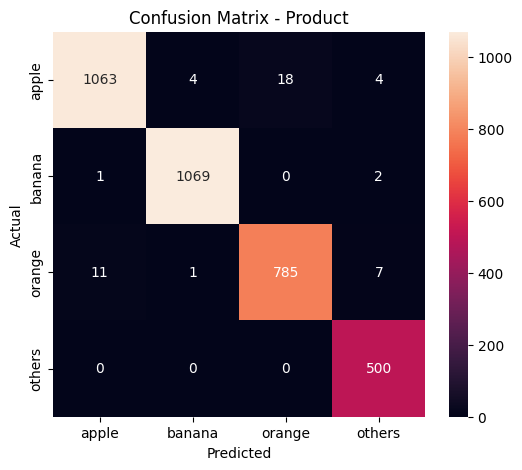

In [20]:
cm_prod = confusion_matrix(y_true_p, y_pred_p)

plt.figure(figsize=(6,5))
sns.heatmap(cm_prod, annot=True, fmt="d",
            xticklabels=le_product.classes_,
            yticklabels=le_product.classes_)
plt.title("Confusion Matrix - Product")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

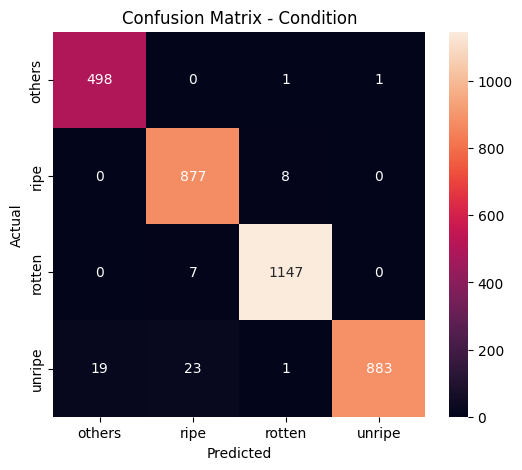

 Confusion matrix dicatat ke TensorBoard: /kaggle/working/logs/20260514-182111/test


In [21]:
cm_cond = confusion_matrix(y_true_c, y_pred_c)

plt.figure(figsize=(6,5))
sns.heatmap(cm_cond, annot=True, fmt="d",
            xticklabels=le_condition.classes_,
            yticklabels=le_condition.classes_)
plt.title("Confusion Matrix - Condition")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Log confusion matrix ke TensorBoard SETELAH plt.show() selesai
# (dilakukan di sini agar tampilan notebook tidak terganggu)
log_confusion_matrix_tb(test_writer, y_true_p, y_pred_p,
                         list(le_product.classes_),  tag="product")
log_confusion_matrix_tb(test_writer, y_true_c, y_pred_c,
                         list(le_condition.classes_), tag="condition")
test_writer.flush()
test_writer.close()
print(f" Confusion matrix dicatat ke TensorBoard: {LOG_DIR}/test")

In [22]:
# model.save(os.path.join(BASE_DIR,"fruit_model.keras"))
model.save("/kaggle/working/fruit_model.keras")

In [23]:
# kemas log TensorBoard untuk disertakan di repository
import shutil

zip_path = "/kaggle/working/tensorboard_logs"
shutil.make_archive(
    base_name=zip_path,
    format="zip",
    root_dir="/kaggle/working",
    base_dir="logs"
)

size_mb = os.path.getsize(zip_path + ".zip") / 1024 / 1024
print(f"Log dikemas: {zip_path}.zip ({size_mb:.2f} MB)")


Log dikemas: /kaggle/working/tensorboard_logs.zip (0.61 MB)


In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, output_index=1, class_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        # pilih output head
        preds = predictions[output_index]

        if class_index is None:
            class_index = tf.argmax(preds[0])

        class_channel = preds[:, class_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

In [25]:
def show_all_classes_gradcam(img_path, model, last_conv_layer_name):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    class_names = list(le_condition.classes_)
    num_classes = len(class_names)
    # Buat figsize dinamis berdasarkan jumlah kelas
    plt.figure(figsize=(num_classes * 4, 4))

    for i, name in enumerate(class_names):
        heatmap = make_gradcam_heatmap(
            img_array,
            model,
            last_conv_layer_name,
            output_index=1,
            class_index=i
        )

        # Resize heatmap agar ukurannya sama persis dengan original (224x224)
        heatmap = cv2.resize(heatmap, (224, 224))
        
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        original = cv2.imread(img_path)
        original = cv2.resize(original, (224,224))


        superimposed = cv2.addWeighted(original, 0.6, heatmap, 0.4, 0)

        plt.subplot(1,num_classes,i+1)
        plt.title(name)
        plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
        plt.axis("off")

    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_270']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


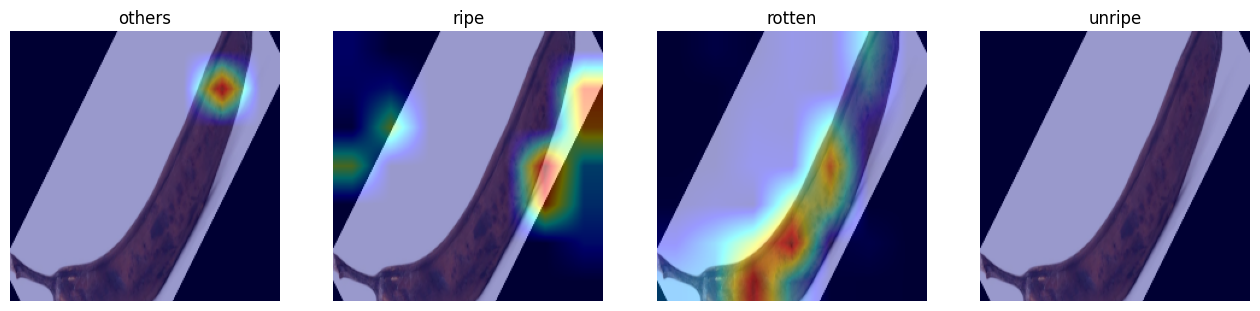

In [26]:
sample_path = test_df.iloc[0]["full_path"]

show_all_classes_gradcam(
    sample_path,
    model,
    "spatial_attention_layer" 
)

## **9. INFERENCE**

In [27]:
def predict_image(img_path):
    if not os.path.exists(img_path):
        return {"error": "file not found"}

    # 1. Preprocess: HAPUS pembagian / 255.0
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) 
    img_array = np.expand_dims(img_array, axis=0) 

    # 2. Inferensi
    pred_prod, pred_cond = model.predict(img_array, verbose=0)

    prod_idx = int(np.argmax(pred_prod[0]))
    cond_idx = int(np.argmax(pred_cond[0]))

    # Translate index ke label asli
    product   = le_product.inverse_transform([prod_idx])[0]
    condition = le_condition.inverse_transform([cond_idx])[0]

    product_confidence = float(np.max(pred_prod[0]))
    condition_confidence = float(np.max(pred_cond[0]))

    # 3. Logika Penanganan Kelas 'Others'
    if product == "others" or condition == "others" or product_confidence < 0.50:
        return {
            "prediction": {
                "product":    "Bukan Buah",
                "condition":  "N/A",
                "suggestion": "Objek tidak dikenali. Mohon foto Apel, Jeruk, atau Pisang."
            },
            "confidence": {
                "product_confidence":   product_confidence,
                "condition_confidence": 0.0
            },
            "freshness_score": 0.0
        }

    # 4. Kalkulasi Freshness Score (Hanya untuk buah asli)
    if condition == "unripe":
        verdict = "Mentah"
        freshness_score = 100
    elif condition == "ripe":
        verdict = "Matang"
        freshness_score = 65 + (condition_confidence * 35)
    elif condition == "rotten":
        verdict = "Busuk"
        freshness_score = 50 - (condition_confidence * 25)
    else:
        verdict = "Unknown"
        freshness_score = 0.0

    return {
        "prediction": {
            "product":    product,
            "condition":  condition,
            "suggestion": verdict
        },
        "confidence": {
            "product_confidence":   product_confidence,
            "condition_confidence": condition_confidence
        },
        "freshness_score": round(max(0, min(100, freshness_score)), 2)
    }


I0000 00:00:1778783409.997370      70 service.cc:152] XLA service 0x78afa82995e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778783409.997428      70 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778783409.997434      70 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-05-14 18:30:16.202644: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-14 18:30:16.337378: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1778783418.622850      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for th

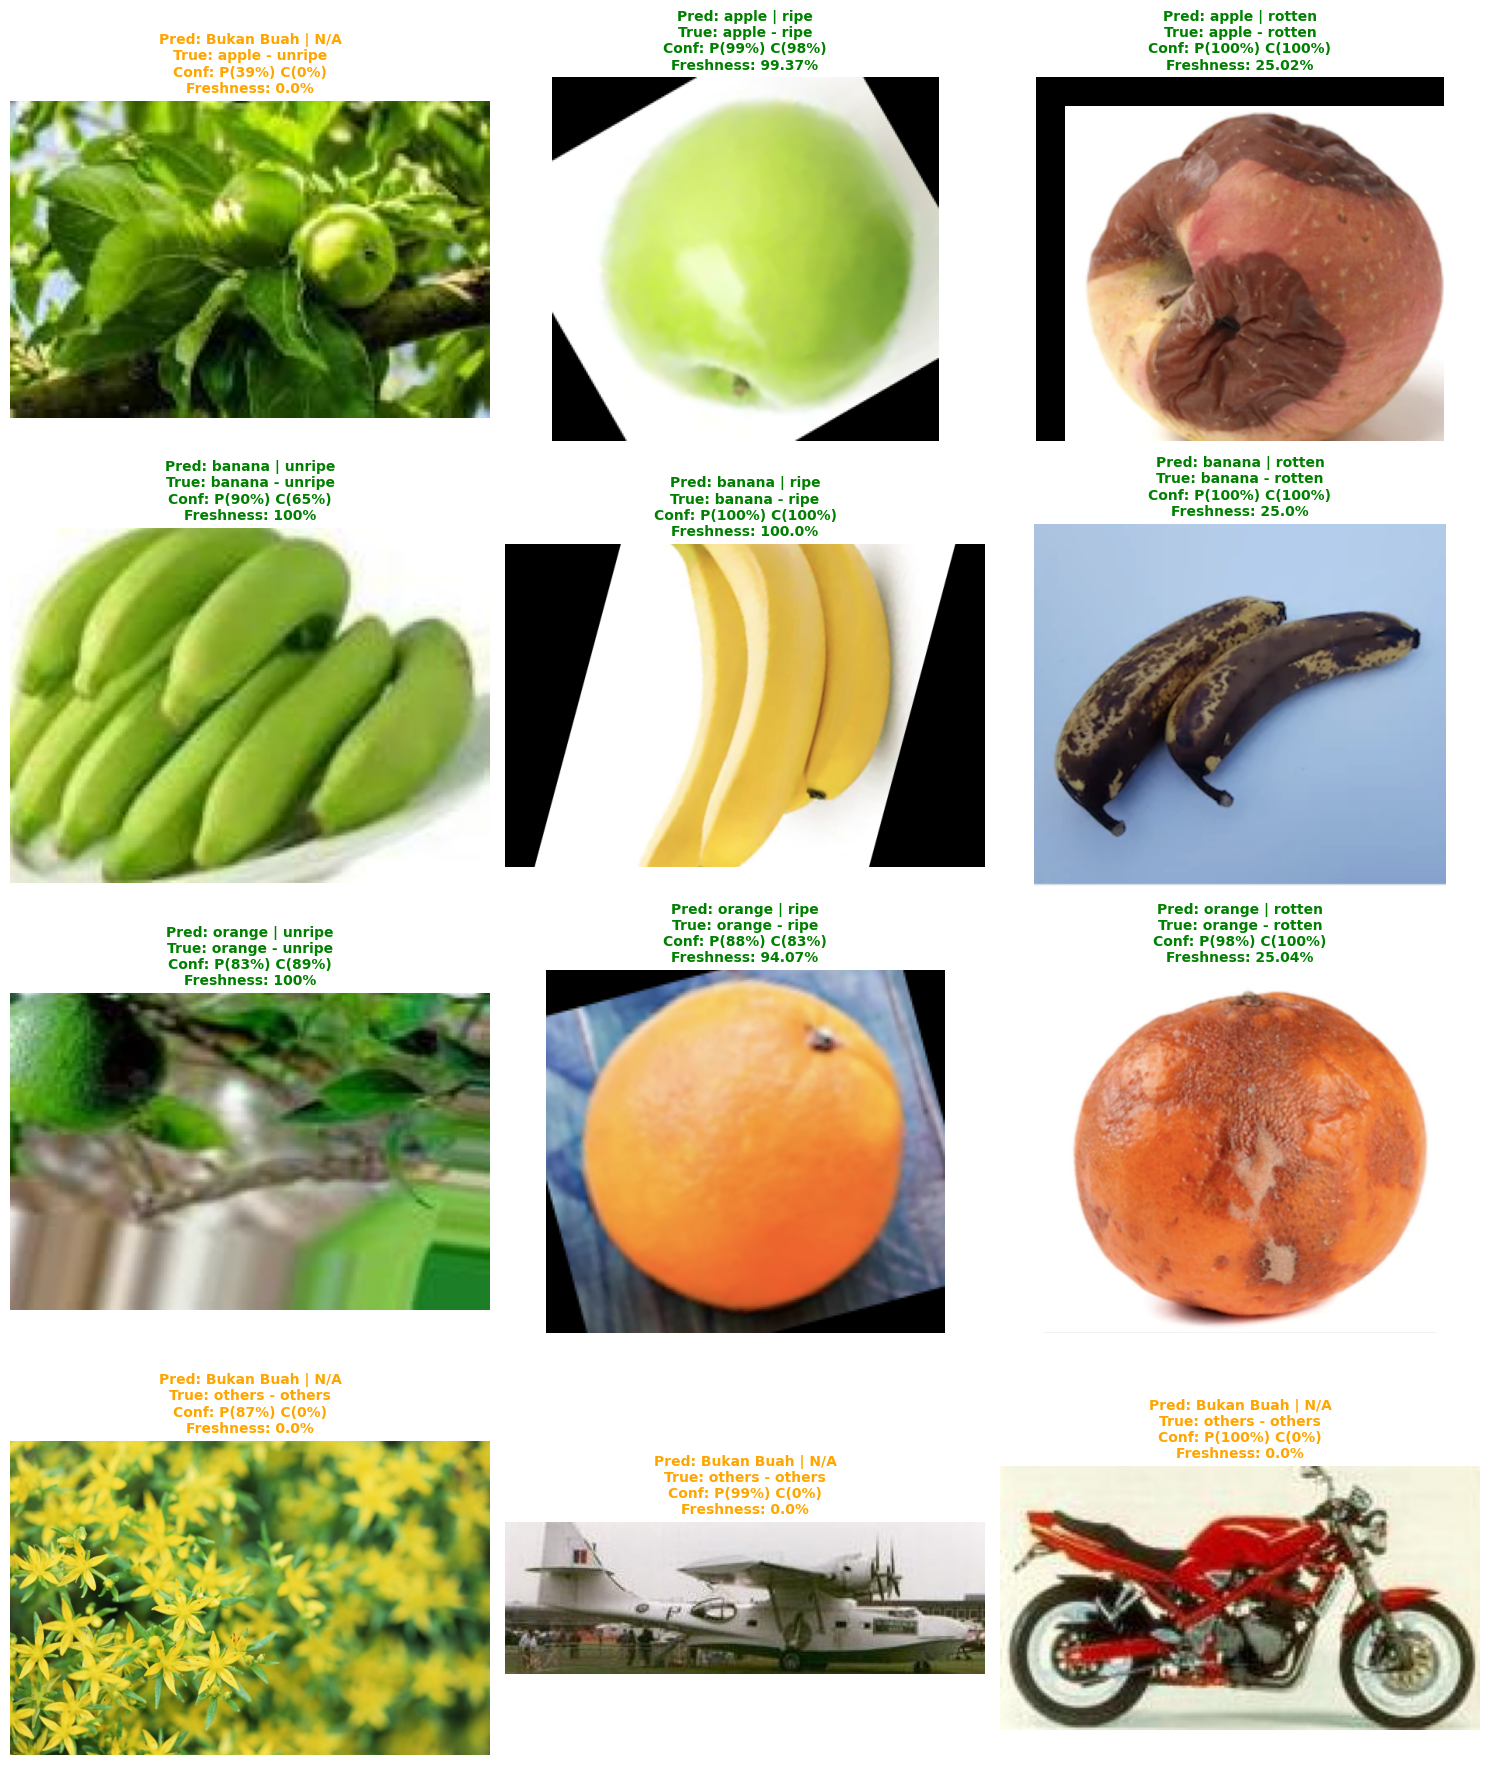

In [28]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. Definisikan kombinasi yang ingin ditampilkan
fruits = ['apple', 'banana', 'orange']
conditions = ['unripe', 'ripe', 'rotten']
sample_indices = []

# Ambil 3 kondisi untuk tiap 3 buah (Total 9)
for f in fruits:
    for c in conditions:
        matches = test_df[(test_df['fruit'] == f) & (test_df['condition'] == c)]
        if not matches.empty:
            idx = matches.sample(1).index[0]
            sample_indices.append(idx)

# Tambahkan 3 foto 'others' (Total jadi 12)
others_matches = test_df[test_df['fruit'] == 'others']
if not others_matches.empty:
    others_samples = others_matches.sample(min(3, len(others_matches))).index.tolist()
    sample_indices.extend(others_samples)

# 2. Visualisasi dalam Grid 4 baris x 3 kolom (atau sebaliknya)
plt.figure(figsize=(15, 18))

for i, idx in enumerate(sample_indices):
    row    = test_df.loc[idx]
    img    = Image.open(row["full_path"])
    result = predict_image(row["full_path"])

    pred_product   = result["prediction"]["product"]
    pred_condition = result["prediction"]["condition"]
    suggestion     = result["prediction"]["suggestion"]
    conf_prod      = result["confidence"]["product_confidence"]
    conf_cond      = result["confidence"]["condition_confidence"]
    freshness      = result["freshness_score"]

    # Pewarnaan
    if pred_product == "Bukan Buah":
        color = "orange"
        is_correct = (row["fruit"] == "others")
    else:
        is_correct = (pred_product == row["fruit"]) and (pred_condition == row["condition"])
        color = "green" if is_correct else "red"

    plt.subplot(4, 3, i+1) # Grid 4x3
    plt.imshow(img)
    plt.axis("off")

    title_text = (
        f"Pred: {pred_product} | {pred_condition}\n"
        f"True: {row['fruit']} - {row['condition']}\n"
        f"Conf: P({conf_prod:.0%}) C({conf_cond:.0%})\n"
        f"Freshness: {freshness}%"
    )

    plt.title(title_text, color=color, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()
